# Toronto Consulting Services Expenditures, 2017-2024

An analytic walk-through of the City of Toronto's external consulting spend over eight years.

**Source:** [Toronto Open Data — Consulting Services Expenditures](https://open.toronto.ca/dataset/consulting-services-expenditures/)

**Sections**
1. Setup & load
2. Headline numbers
3. Where does the money go? (divisions, categories)
4. Vendor concentration
5. Investigative deep-dives
6. Anomaly detection — contracts worth a second look
7. Takeaways

## 1. Setup & load

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))

import pandas as pd, numpy as np
import matplotlib.pyplot as plt

import analyze, anomaly
analyze._style()

df = analyze.load()
print(f'{len(df):,} contracts, {df["year"].min()}-{df["year"].max()}, ${df["expenditure"].sum()/1e6:.1f}M total spend')
df.head()

3,678 contracts, 2017-2024, $350.2M total spend


,year,budget_type,city_abc,expense_category,division_board,contract_date,contract_number,consultant_name,description,expenditure,source_file,source_sheet
0,2017,Operating,Finance and Treasury Services,Legal (External Lawyers & Planners),"Pension, Payroll and Employee Benefits",2012-07-22,6035311,"Osler, Hoskin & Harcourt, LLP",Legal advice regarding pensions and other empl...,150217.0,2017-2021-consulting-database-xlsx.xlsx,2017 Consult Exp
1,2017,Operating,Finance and Treasury Services,Legal (External Lawyers & Planners),"Pension, Payroll and Employee Benefits",2013-07-16,6037517,Dentons Canada LLP,Legal advice regarding Canada Revenue Agency (...,571.0,2017-2021-consulting-database-xlsx.xlsx,2017 Consult Exp
2,2017,Operating,Agencies and Corporations,Management / Research & Development,Toronto Transit Commission,2014-03-27,194640,Imex Systems Inc.,Review business processes and systems and reco...,1978.0,2017-2021-consulting-database-xlsx.xlsx,2017 Consult Exp
3,2017,Operating,Agencies and Corporations,Technical,Toronto Transit Commission,2015-04-07,C32PT15785,CH2M Hill Canada Ltd,Study on the Bus Terminal Capacity supporting ...,32538.0,2017-2021-consulting-database-xlsx.xlsx,2017 Consult Exp
4,2017,Operating,Agencies and Corporations,Technical,Toronto Transit Commission,2015-04-07,C32PT15785,CH2M Hill Canada Ltd,Perform Functional Review of TTC Service Deliv...,297719.0,2017-2021-consulting-database-xlsx.xlsx,2017 Consult Exp


## 2. Headline numbers

Annual totals, contract counts, and median contract size.

In [2]:
yt = analyze.yearly_totals(df)
display(yt.style.format({
    'total_spend': '${:,.0f}',
    'median_contract': '${:,.0f}',
    'yoy_growth': '{:+.1%}',
}))
analyze.plot_yearly_totals(df)

,year,total_spend,contracts,median_contract,unique_vendors,yoy_growth
0,2017,"$21,428,265",264,"$33,066",144,+nan%
1,2018,"$25,334,106",306,"$29,250",177,+18.2%
2,2019,"$37,855,132",434,"$33,760",243,+49.4%
3,2020,"$42,274,577",413,"$29,058",233,+11.7%
4,2021,"$45,656,295",516,"$26,178",273,+8.0%
5,2022,"$59,811,344",573,"$27,894",286,+31.0%
6,2023,"$57,650,181",569,"$25,000",293,-3.6%
7,2024,"$60,235,636",603,"$25,000",289,+4.5%


  wrote C:\Users\winsb\Toronto-Consulting-Services-Expenditures-Analysis\reports\figures\01_yearly_totals.png


**Takeaway.** Total consulting spend nearly tripled from 2017 ($21M) to 2024 ($60M). Most of the growth landed in 2019-2022, with spend essentially flat from 2022 onward. The number of unique vendors also grew, but more slowly — meaning average spend per vendor is up.

## 3. Where does the money go?

By expense category and by division/board.

In [3]:
display(analyze.by_expense_category(df).head(10).style.format({'total_spend': '${:,.0f}'}))
analyze.plot_expense_category(df)

,expense_category,total_spend,contracts
0,Technical,"$156,812,663",1875
1,Management / Research & Development,"$97,264,551",1087
2,Information Technology,"$71,442,695",210
3,Legal (External Lawyers & Planners),"$9,796,435",160
4,Legal,"$9,375,936",156
5,Creative Communications,"$5,553,257",190


  wrote C:\Users\winsb\Toronto-Consulting-Services-Expenditures-Analysis\reports\figures\05_expense_category.png


In [4]:
display(analyze.by_division(df).head(15).style.format({'total_spend': '${:,.0f}'}))
analyze.plot_by_division(df)

,division_board,total_spend,contracts
0,Toronto Transit Commission,"$87,705,981",519
1,Transportation Services,"$62,184,378",653
2,Office of the Controller,"$40,692,256",64
3,Strategic Enterprise Integration and Modernization,"$17,282,422",30
4,City Planning,"$15,071,649",323
5,Purchasing and Materials Management,"$13,768,122",8
6,Toronto Police Service,"$12,366,490",189
7,Toronto Community Housing Corporation,"$9,678,512",151
8,TO Live,"$9,588,668",354
9,Toronto Waterfront Revitalization Corporation,"$7,404,849",170


  wrote C:\Users\winsb\Toronto-Consulting-Services-Expenditures-Analysis\reports\figures\04_top_divisions.png

In [5]:
analyze.plot_division_growth(df)

  wrote C:\Users\winsb\Toronto-Consulting-Services-Expenditures-Analysis\reports\figures\06_division_growth.png


**Takeaway.** "Technical" and "Management / Research & Development" together account for the lion's share of spend. A small number of divisions absorb most of the budget — the long tail is genuinely long.

## 4. Vendor concentration

How concentrated is consulting spend among a few firms? We look at top-10 vendor share and the Herfindahl-Hirschman Index (HHI) per year.

In [6]:
tv = analyze.top_vendors(df, n=15)
display(tv.style.format({'total_spend': '${:,.0f}', 'share_of_total': '{:.1%}'}))
analyze.plot_top_vendors(df)

,consultant_name,total_spend,contracts,years_active,share_of_total
0,Deloitte LLP,"$48,358,824",36,8,13.8%
1,Ernst & Young LLP,"$34,193,164",83,8,9.8%
2,KPMG LLP,"$17,370,077",105,8,5.0%
3,WSP Canada Inc.,"$16,289,710",175,8,4.7%
4,CH2M Hill Canada Ltd,"$12,802,999",61,7,3.7%
5,Hatch Ltd.,"$7,693,730",43,4,2.2%
6,LEA Consulting Ltd,"$6,955,078",77,8,2.0%
7,CIMA Canada Inc.,"$5,953,545",63,7,1.7%
8,HDR Corporation,"$5,729,141",55,8,1.6%
9,Atkins Realis Operations & Maintenance Inc.,"$5,724,397",3,2,1.6%


  wrote C:\Users\winsb\Toronto-Consulting-Services-Expenditures-Analysis\reports\figures\02_top_vendors.png


In [7]:
vc = analyze.vendor_concentration(df)
display(vc.style.format({'top10_share': '{:.1%}', 'hhi': '{:.0f}'}))
analyze.plot_concentration(df)

,year,top10_share,hhi,num_vendors
0,2017,46.8%,340,144
1,2018,47.5%,441,177
2,2019,44.1%,319,243
3,2020,51.7%,399,233
4,2021,48.8%,352,273
5,2022,62.5%,820,286
6,2023,62.7%,1312,293
7,2024,61.2%,768,289


  wrote C:\Users\winsb\Toronto-Consulting-Services-Expenditures-Analysis\reports\figures\03_concentration.png


**Takeaway.** The Big 4 (Deloitte, EY, KPMG, plus WSP) dominate the cumulative leaderboard. Deloitte alone accounts for ~14% of all eight-year spend. The HHI hovers in the moderately-concentrated range, with the top 10 vendors capturing a large share of yearly spend.

## 5. Investigative deep-dives

Three questions:
1. Which divisions grew their consulting spend fastest?
2. Are the top vendors becoming *more* dominant, or are new entrants rising?
3. What is the contract-size distribution telling us? (Lots of small, a few huge?)

In [8]:
# Q1 — divisions with the biggest absolute growth from 2017->2024
by_year = df.pivot_table(index='division_board', columns='year', values='expenditure', aggfunc='sum').fillna(0)
if 2017 in by_year.columns and 2024 in by_year.columns:
    growth = (by_year[2024] - by_year[2017]).sort_values(ascending=False).head(10)
    display(growth.to_frame('growth_2017_to_2024_$').style.format('${:,.0f}'))

,growth_2017_to_2024_$
division_board,
Strategic Enterprise Integration and Modernization,"$17,282,422"
Toronto Transit Commission,"$8,310,118"
Transportation Services,"$6,994,812"
Toronto Zoo,"$1,810,493"
Toronto Community Housing Corporation,"$1,775,870"
TO Live,"$1,692,572"
Solid Waste Management,"$837,271"
"Social Development, Finance and Administration","$715,427"
Housing Secretariat,"$542,698"


is_big4,False,True,big4_pct
year,,,
2017,"$20,147,484","$1,280,781",6.0%
2018,"$22,042,338","$3,291,768",13.0%
2019,"$31,642,919","$6,212,213",16.4%
2020,"$32,931,123","$9,343,454",22.1%
2021,"$36,010,553","$9,645,742",21.1%
2022,"$35,279,330","$24,532,014",41.0%
2023,"$30,234,109","$27,416,072",47.6%
2024,"$42,035,616","$18,200,021",30.2%


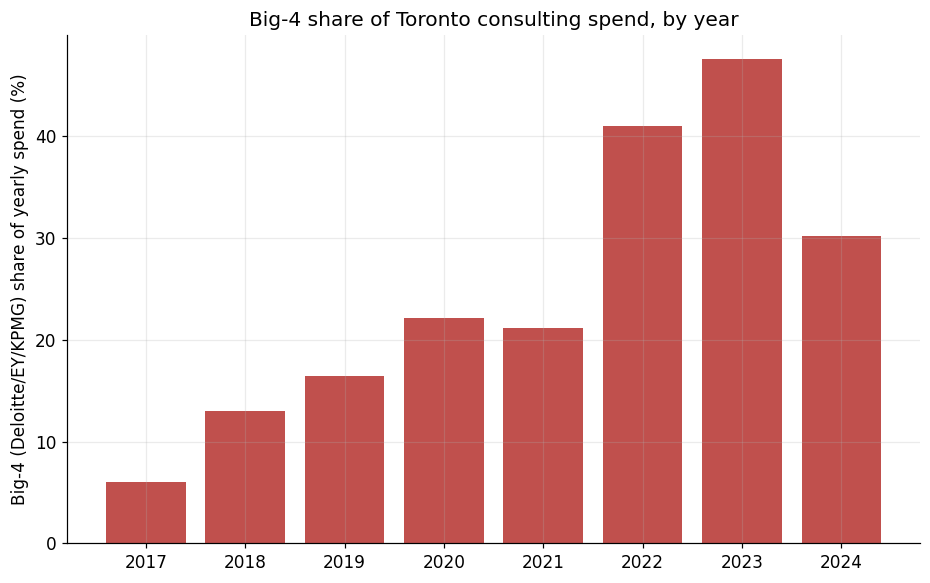

In [9]:
# Q2 — Deloitte / EY / KPMG share of total spend over time
big4 = ['Deloitte LLP', 'Ernst & Young LLP', 'KPMG LLP']
big4_share = (
    df.assign(is_big4=df['consultant_name'].isin(big4))
      .groupby(['year', 'is_big4'])['expenditure'].sum()
      .unstack(fill_value=0)
)
big4_share['big4_pct'] = big4_share[True] / (big4_share[True] + big4_share[False])
display(big4_share.style.format({True: '${:,.0f}', False: '${:,.0f}', 'big4_pct': '{:.1%}'}))

fig, ax = plt.subplots()
ax.bar(big4_share.index, big4_share['big4_pct']*100, color='#c0504d')
ax.set_ylabel('Big-4 (Deloitte/EY/KPMG) share of yearly spend (%)')
ax.set_title('Big-4 share of Toronto consulting spend, by year')
plt.show()

In [10]:
# Q3 — contract-size distribution and pareto curve
analyze.plot_contract_size_distribution(df)

# Pareto: what share of total spend do the top-5% biggest contracts represent?
sorted_amt = df['expenditure'].sort_values(ascending=False).reset_index(drop=True)
cum_share = sorted_amt.cumsum() / sorted_amt.sum()
n = len(sorted_amt)
print(f'Top  1% of contracts ({int(0.01*n):>4} rows) = {cum_share.iloc[int(0.01*n)]:.1%} of spend')
print(f'Top  5% of contracts ({int(0.05*n):>4} rows) = {cum_share.iloc[int(0.05*n)]:.1%} of spend')
print(f'Top 10% of contracts ({int(0.10*n):>4} rows) = {cum_share.iloc[int(0.10*n)]:.1%} of spend')

  wrote C:\Users\winsb\Toronto-Consulting-Services-Expenditures-Analysis\reports\figures\07_contract_size_distribution.png
Top  1% of contracts (  36 rows) = 28.6% of spend
Top  5% of contracts ( 183 rows) = 47.1% of spend
Top 10% of contracts ( 367 rows) = 60.4% of spend


**Takeaway.** Spend is heavily Pareto-distributed: a tiny number of contracts drive the bulk of total spend. That makes the dataset an excellent candidate for anomaly flagging — outliers really do dominate.

## 6. Anomaly detection — contracts worth a second look

Two signals, combined by rank:
* **Category z-score** — how unusual a contract's log-amount is relative to its (year, expense_category) peer group.
* **Isolation Forest** — multivariate score across amount, category, division, budget type, vendor frequency, and contract-date offset.

Use these as a **starting list for human review**, not as accusations.

In [11]:
flagged = anomaly.find_anomalies(df, top_n=25)
display(
    flagged.assign(description=flagged['description'].str.slice(0, 100) + '...')
           .style.format({'expenditure': '${:,.0f}', 'anomaly_score': '{:.3f}'})
)

,year,consultant_name,division_board,expense_category,budget_type,expenditure,description,category_zscore,isoforest_score,anomaly_score
1430,2021,KPMG LLP,Office of the Chief Information Security Officer,Information Technology,Operating,"$1,062,340",To provide consulting services to enhance the City's ransomware resilience to minimize the impact of...,2.255126,0.646860,0.996
3101,2024,Deloitte LLP,Strategic Enterprise Integration and Modernization,Information Technology,Capital,"$13,715,432",To provide consulting services for the Preparation Phase related to Financial Systems Transformation...,2.940879,0.632028,0.996
2801,2023,Deloitte LLP,Office of the Controller,Information Technology,Capital,"$18,956,279",To provide consulting services for the Preparation Phase related to Financial Systems Transformation...,3.071094,0.628736,0.995
109,2017,Davies Ward Phillips & Vineberg LLP,Facilities Management,Legal (External Lawyers & Planners),Capital,"$219,761",Legal advice for the selection of qualified potential lessees and negotiations with stakeholders; GO...,2.205948,0.636205,0.994
2329,2022,Ernst & Young LLP,Purchasing and Materials Management,Management / Research & Development,Operating,"$5,073,426",To provide services to support the execution of Phase 2 and to identify new opportunities for saving...,3.342158,0.619684,0.993
1951,2022,Ernst & Young LLP,Office of the Controller,Information Technology,Capital,"$2,656,404","To provide active risk management advisory support, including developing a procurement strategy for ...",2.227559,0.625388,0.992
1952,2022,Deloitte LLP,Office of the Controller,Information Technology,Capital,"$11,122,028",To provide consulting services for the Preparation Phase related to Financial Systems Transformation...,3.049092,0.610313,0.991
2800,2023,Ernst & Young LLP,Office of the Controller,Information Technology,Capital,"$2,788,707","To provide active risk management advisory support, including developing a procurement strategy for ...",2.053030,0.626302,0.990
1018,2020,Ernst & Young LLP,Purchasing and Materials Management,Management / Research & Development,Operating,"$1,719,545",Professional Services for the implementation of Category Management and Strategic Sourcing (CMSS) wi...,2.391978,0.609122,0.989
2274,2022,Davies Ward Phillips & Vineberg LLP,Corporate Real Estate Management,Legal,Operating,"$327,654",To provide legal advice in connection with the selection of the qualified potential lessees negotiat...,1.752116,0.671098,0.987


**Notable flag.** The single biggest contract in the entire dataset is a 2023 Deloitte IT engagement at **$18.9M**. It dwarfs everything else in its category-year peer group, and the model picks it out cleanly. Whether it represents a legitimate large transformation program or a contract worth scrutinizing is a question for a human reviewer — but it's the kind of contract that should not pass unnoticed.

## 7. Takeaways

* **Spend nearly tripled** between 2017 and 2024, with most growth landing in 2019-2022.
* **Concentration is high.** A few divisions and a few vendors (Deloitte, EY, KPMG, WSP) dominate.
* **Pareto distribution.** ~5% of contracts account for the majority of total spend.
* **Anomaly flagging works.** A simple z-score + Isolation Forest combo cleanly surfaces the largest and most unusual contracts for review.